In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
from astropy.visualization import ZScaleInterval

In [7]:
df = pd.read_csv('../Week 2/berk59_gaia.csv')
print(len(df))

8991


In [9]:
df.head(
)

,source_id,ra,dec,parallax,pmra,pmdec,phot_g_mean_mag,bp_rp,ruwe
0,528398247196057984,1.485742,66.753550,1.004678,4.041726,-0.329621,18.762821,2.538010,0.929814
1,528428277606634240,0.645624,66.641058,0.771321,-7.471687,1.196896,16.031860,2.195567,0.930125
2,528428866021097472,0.433390,66.613762,0.910603,-2.831429,-1.338799,16.497929,2.079200,1.001370
3,528430206050882944,0.193307,66.620978,0.320436,-2.421477,-1.218671,14.895183,3.168274,0.993971
4,528431477361185664,0.145478,66.665763,0.314307,-1.660312,-2.460049,15.871153,2.836157,1.013742


In [10]:
pmra_c  = np.median(df.pmra)
pmdec_c = np.median(df.pmdec)

R_pm = 0.3  
mask = (df.pmra - pmra_c)**2 + (df.pmdec - pmdec_c)**2 < R_pm**2

members = df[mask].copy()
print("Cluster members:", len(members))

Cluster members: 102


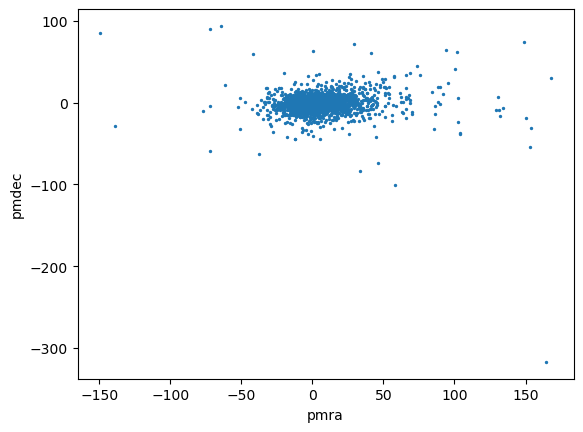

In [14]:

## all members
plt.scatter(df.pmra, df.pmdec, s=2)
plt.xlabel('pmra')
plt.ylabel('pmdec')
plt.show()

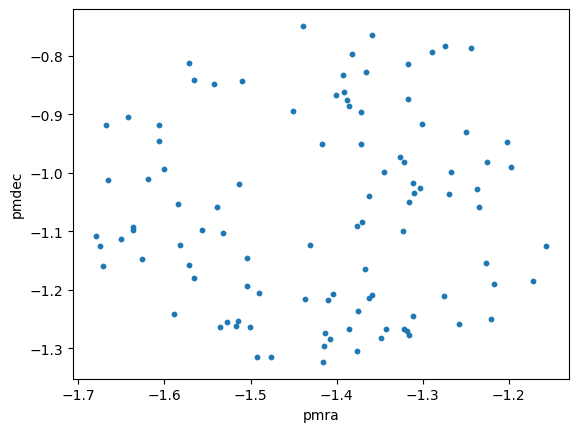

In [15]:


## cluster members
plt.scatter(members.pmra, members.pmdec, s=10)
plt.xlabel('pmra')
plt.ylabel('pmdec')
plt.show()

In [17]:
members

,source_id,ra,dec,parallax,pmra,pmdec,phot_g_mean_mag,bp_rp,ruwe
30,528456796189656064,0.312459,66.822009,0.894611,-1.225824,-1.153904,18.660112,2.865688,0.941444
141,528582522771463168,0.908595,67.433427,0.928392,-1.413930,-1.272881,15.788016,2.617037,1.217562
177,528607639740035072,0.041197,67.799025,0.965469,-1.538857,-1.058398,15.566223,2.214842,1.006849
275,528492534616912256,1.572158,66.824861,0.404891,-1.390921,-0.862358,17.495682,1.940405,1.001373
324,528551491629002624,1.334544,67.188112,1.114979,-1.343029,-1.267404,18.721996,3.123045,1.037123
...,...,...,...,...,...,...,...,...,...
8564,528970439918180096,0.779978,67.883688,1.047661,-1.359039,-1.208277,17.479532,2.903616,0.980480
8581,528982775064276608,0.545164,67.905362,1.222814,-1.436865,-1.215599,18.549864,3.117641,1.096499
8790,2210101801574190464,358.442155,67.427883,0.701252,-1.675042,-1.125349,16.047200,2.350793,0.999673
8876,2210910350638377088,359.652829,68.116865,0.426752,-1.650814,-1.113525,17.481882,1.918640,1.099654


In [5]:
from astropy.io import fits
bands = ['g','r','i'] # different wavelength bands
images = {}
headers = {}
for b in bands:
    images[b] = fits.open(f'Berk_{b}.wcs.proc.fits')[0].data # importing the fits files (telescope images)
    headers[b] = fits.open(f'Berk_{b}.wcs.proc.fits')[0].header

In [2]:
import sys
!{sys.executable} -m pip install photutils
from photutils.detection import DAOStarFinder
from photutils.aperture import CircularAperture, aperture_photometry
from astropy.stats import sigma_clipped_stats
from astropy.coordinates import SkyCoord
import astropy.units as u

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 873.4/873.4 kB 7.8 MB/s eta 0:00:00


In [4]:
def detect_stars(data, fwhm=3.0, threshold_sigma=5.0):
    mean, median, std = sigma_clipped_stats(data, sigma=3.0)
    daofind = DAOStarFinder(fwhm=fwhm, threshold=threshold_sigma * std)
    sources = daofind(data - median)
    return sources

In [5]:
def do_photometry(data, sources, aperture_radius=4.0):
    positions = np.transpose((sources['xcentroid'], sources['ycentroid']))
    apertures = CircularAperture(positions, r=aperture_radius)
    phot_table = aperture_photometry(data, apertures)
    return phot_table

In [4]:
phot_tables = {}

for b in ['g', 'r', 'i']:
    data = images[b]
    sources = detect_stars(data)
    phot = do_photometry(data, sources)

    phot['inst_mag'] = -2.5 * np.log10(phot['aperture_sum'])
    phot_tables[b] = phot

KeyError: 'g'

In [7]:
from astropy.wcs.utils import pixel_to_skycoord

sky_tables = {}

for b in ['g', 'r', 'i']:
    wcs = WCS(headers[b])
    phot = phot_tables[b]

    coords = pixel_to_skycoord(
        phot['xcenter'], phot['ycenter'], wcs
    )

    phot['ra'] = coords.ra.deg
    phot['dec'] = coords.dec.deg

    sky_tables[b] = phot

ModuleNotFoundError: No module named 'astropy'

In [8]:
gaia_coords = SkyCoord(
    members.ra.values * u.deg,
    members.dec.values * u.deg
)

matched = {}

for b in ['g', 'r', 'i']:
    phot = sky_tables[b]

    phot_coords = SkyCoord(
        phot['ra'] * u.deg,
        phot['dec'] * u.deg
    )

    idx, sep, _ = phot_coords.match_to_catalog_sky(gaia_coords)

    mask = sep < 1.0 * u.arcsec

    phot = phot[mask]
    phot['gaia_index'] = idx[mask]

    matched[b] = phot

NameError: name 'SkyCoord' is not defined

In [9]:
ZP = {}

for b in ['g', 'r', 'i']:
    phot = matched[b]

    if b == 'g':
        gaia_mag = members.iloc[phot['gaia_index']]['phot_g_mean_mag'].values
    elif b == 'r':
        gaia_mag = members.iloc[phot['gaia_index']]['phot_g_mean_mag'].values
    elif b == 'i':
        gaia_mag = members.iloc[phot['gaia_index']]['phot_g_mean_mag'].values

    zp = np.median(gaia_mag - phot['inst_mag'])
    ZP[b] = zp

    print(f"{b}-band ZP =", zp)

NameError: name 'matched' is not defined

In [10]:
A_ext = {
    'g': 0.233,
    'r': 0.130,
    'i': 0.078
}

In [11]:
calibrated = {}

for b in ['g', 'r', 'i']:
    phot = matched[b]
    phot[f'{b}_sdss'] = phot['inst_mag'] + ZP[b] - A_ext[b]
    calibrated[b] = phot

NameError: name 'matched' is not defined

In [12]:
cmd = pd.DataFrame({
    'g': calibrated['g']['g_sdss'],
    'r': calibrated['r']['r_sdss'],
    'i': calibrated['i']['i_sdss']
})

cmd['g_r'] = cmd['g'] - cmd['r']
cmd['r_i'] = cmd['r'] - cmd['i']

NameError: name 'pd' is not defined

In [13]:
plt.figure(figsize=(6,8))
plt.scatter(cmd['r_i'], cmd['i'], c=cmd['g'], cmap='viridis', s=50)
plt.gca().invert_yaxis()
plt.xlabel(r'$(r - i)$')
plt.ylabel(r'$i$')
plt.title('CMD: $(r - i)$ vs $i$')
plt.colorbar(label='g [mag]')
plt.show()

NameError: name 'plt' is not defined

In [14]:
plt.figure(figsize=(6,8))
plt.scatter(cmd['g_r'], cmd['r'], c=cmd['i'], cmap='plasma', s=50)
plt.gca().invert_yaxis()
plt.xlabel(r'$(g - r)$')
plt.ylabel(r'$r$')
plt.title('CMD: $(g - r)$ vs $r$')
plt.colorbar(label='i [mag]')
plt.show()

NameError: name 'plt' is not defined